# MMIA 6013 · Taller 01

# Parte 4.a — Barrido de esfuerzo


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

from src.config import (
    OPENAI_API_KEY,
    OPENAI_REASONING_MODEL,
    validate_environment
)

validate_environment()

client = OpenAI(api_key=OPENAI_API_KEY)

In [3]:
cases = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "casos.csv"
)

cases

,id,ticket,expected
0,1,Employee cannot access payroll after password ...,HR
1,2,The monthly salary was deposited twice into my...,Finance
2,3,VPN connection fails when working remotely.,Technical
3,4,Request to update bank account for direct depo...,HR
4,5,Credit card payment appears duplicated in tran...,Finance
5,6,Laptop shows a blue screen during startup.,Technical
6,7,Need an employment verification letter for vis...,HR
7,8,Interest calculation on a mortgage statement s...,Finance
8,9,Email client cannot synchronize with the corpo...,Technical
9,10,Update my home address in employee records.,HR


In [4]:
PROMPT = """
You are a support ticket classifier.

Classify the ticket into exactly one category:

- HR
- Finance
- Technical

Return only the category name.

Ticket:
{ticket}
"""

In [5]:
reasoning={"effort": "low"}

In [6]:
EFFORT_LEVELS = ["low", "medium", "high"]

In [7]:
def run_reasoning(ticket, effort):

    prompt = PROMPT.format(ticket=ticket)

    start = time.perf_counter()

    response = client.responses.create(
        model=OPENAI_REASONING_MODEL,
        input=prompt,
        reasoning={
            "effort": effort
        }
    )

    latency = time.perf_counter() - start

    usage = response.usage

    reasoning_tokens = (
        usage.output_tokens_details.reasoning_tokens
        if usage.output_tokens_details
        else 0
    )

    visible_tokens = usage.output_tokens - reasoning_tokens

    return {
        "response": response.output_text.strip(),
        "input_tokens": usage.input_tokens,
        "output_tokens": usage.output_tokens,
        "reasoning_tokens": reasoning_tokens,
        "visible_tokens": visible_tokens,
        "latency": latency
    }

In [9]:
def benchmark_reasoning_effort(cases):

    rows = []

    for effort in EFFORT_LEVELS:

        for _, row in cases.iterrows():

            result = run_reasoning(
                row.ticket,
                effort
            )

            prediction = result["response"].strip()

            rows.append({
                "effort": effort,
                "case_id": row.id,
                "expected": row.expected,
                "prediction": prediction,
                "correct": prediction == row.expected,
                "latency": result["latency"],
                "input_tokens": result["input_tokens"],
                "output_tokens": result["output_tokens"],
                "reasoning_tokens": result["reasoning_tokens"],
                "visible_tokens": result["visible_tokens"]
            })

    return pd.DataFrame(rows)

In [20]:
reasoning_results = benchmark_reasoning_effort(cases)

reasoning_results.head()

,effort,case_id,expected,prediction,correct,latency,input_tokens,output_tokens,reasoning_tokens,visible_tokens
0,low,1,HR,Technical,False,1.900088,48,37,30,7
1,low,2,Finance,Finance,True,1.922222,50,5,0,5
2,low,3,Technical,Technical,True,1.325346,47,5,0,5
3,low,4,HR,HR,True,1.365304,49,5,0,5
4,low,5,Finance,Finance,True,1.131812,49,5,0,5


In [21]:
INPUT_PRICE = 0.20
OUTPUT_PRICE = 1.20

reasoning_results["cost_usd"] = (
    reasoning_results["input_tokens"] / 1_000_000 * INPUT_PRICE
    + reasoning_results["output_tokens"] / 1_000_000 * OUTPUT_PRICE
)

In [22]:
reasoning_summary = (
    reasoning_results
    .groupby("effort")
    .agg(
        accuracy=("correct", "mean"),
        reasoning_tokens=("reasoning_tokens", "mean"),
        visible_tokens=("visible_tokens", "mean"),
        latency=("latency", "mean"),
        cost_usd=("cost_usd", "mean")
    )
    .reset_index()
)

reasoning_summary["accuracy"] *= 100

reasoning_summary = reasoning_summary.round({
    "accuracy": 1,
    "reasoning_tokens": 1,
    "visible_tokens": 1,
    "latency": 2,
    "cost_usd": 6
})

reasoning_summary

,effort,accuracy,reasoning_tokens,visible_tokens,latency,cost_usd
0,high,80.0,3.6,5.2,1.42,0.00002
1,low,90.0,3.0,5.2,1.50,0.00002
2,medium,90.0,3.2,5.2,1.44,0.00002


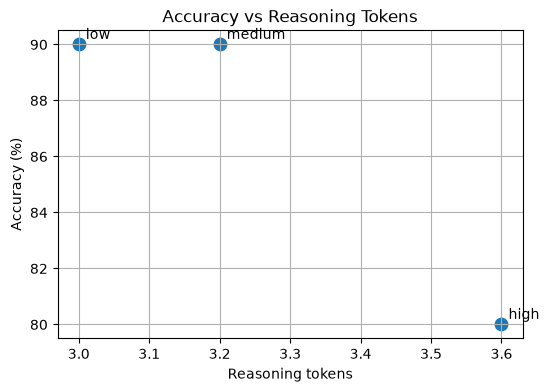

In [25]:
plt.figure(figsize=(6,4))

# Gráfica de dispersión
plt.scatter(
    reasoning_summary["reasoning_tokens"],
    reasoning_summary["accuracy"],
    s=80
)

# Etiquetas de cada punto
for _, row in reasoning_summary.iterrows():
    plt.text(
        row["reasoning_tokens"] + 0.01,
        row["accuracy"] + 0.2,
        row["effort"],
        fontsize=10
    )

plt.xlabel("Reasoning tokens")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Reasoning Tokens")
plt.grid(True)

plt.show()

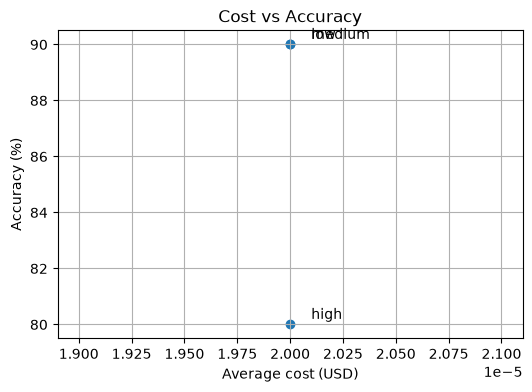

In [26]:
plt.figure(figsize=(6,4))

plt.scatter(
    reasoning_summary["cost_usd"],
    reasoning_summary["accuracy"],
    marker="o"
)

for _, row in reasoning_summary.iterrows():
    plt.text(
        row["cost_usd"] + 0.0000001,
        row["accuracy"] + 0.2,
        row["effort"]
    )

plt.xlabel("Average cost (USD)")
plt.ylabel("Accuracy (%)")
plt.title("Cost vs Accuracy")
plt.grid(True)

plt.show()

## Conclusiones — Parte 4.a

Se evaluó el modelo GPT-5.6 utilizando tres niveles de reasoning_effort (low, medium y high) sobre el mismo conjunto de 10 tickets. El objetivo fue determinar si incrementar el esfuerzo de razonamiento mejora la calidad de las respuestas y cómo afecta el consumo de recursos.

Los resultados muestran que los niveles low y medium alcanzaron la mayor exactitud (90 %), mientras que high obtuvo únicamente 80 %. Además, el número promedio de *reasoning tokens* aumentó ligeramente de 3.0 a 3.6, pero este incremento no produjo una mejora en el desempeño. La latencia se mantuvo cercana a 1.5 segundos en los tres casos y el costo promedio fue prácticamente idéntico (≈ USD 0.00002 por consulta).

A partir de estos datos se identifica un punto de rendimientos decrecientes: pasar de medium a high incrementó el razonamiento interno sin aportar beneficios en exactitud. Para esta tarea de clasificación, el esfuerzo adicional no se tradujo en mejores decisiones del modelo.

En consecuencia, medium representa la alternativa más equilibrada, ya que iguala la máxima exactitud obtenida con low y mantiene un consumo de recursos prácticamente igual. Esto evidencia que el nivel de reasoning_effort debe seleccionarse según la complejidad del problema y no asumirse como un parámetro que siempre mejora el rendimiento.

# Parte 4.b — El caso donde pensar más hace daño

In [27]:
contaminated_cases = pd.DataFrame([
    {
        "id": 1,
        "ticket": (
            "My VPN disconnects every few minutes while working remotely. "
            "Yesterday the finance department also sent a reimbursement email, "
            "but my problem is that I cannot keep the VPN connection stable."
        ),
        "expected": "Technical"
    },
    {
        "id": 2,
        "ticket": (
            "Please update my home address in my employee records. "
            "I recently changed banks and my mortgage payment increased, "
            "but I am only requesting an address update."
        ),
        "expected": "HR"
    },
    {
        "id": 3,
        "ticket": (
            "My monthly salary was deposited twice into my account. "
            "IT recently replaced my laptop, but this ticket is about the duplicated salary deposit."
        ),
        "expected": "Finance"
    }
])

contaminated_cases

,id,ticket,expected
0,1,My VPN disconnects every few minutes while wor...,Technical
1,2,Please update my home address in my employee r...,HR
2,3,My monthly salary was deposited twice into my ...,Finance


In [28]:
EFFORTS = ["low", "high"]

def benchmark_contaminated(cases):

    rows = []

    for effort in EFFORTS:

        for _, row in cases.iterrows():

            result = run_reasoning(
                row.ticket,
                effort
            )

            rows.append({
                "effort": effort,
                "case_id": row.id,
                "expected": row.expected,
                "prediction": result["response"],
                "correct": result["response"] == row.expected,
                "reasoning_tokens": result["reasoning_tokens"],
                "latency": result["latency"]
            })

    return pd.DataFrame(rows)

In [31]:
contaminated_results = benchmark_contaminated(
    contaminated_cases
)

contaminated_results

,effort,case_id,expected,prediction,correct,reasoning_tokens,latency
0,low,1,Technical,Technical,True,0,1.864992
1,low,2,HR,HR,True,0,1.270674
2,low,3,Finance,Finance,True,0,1.323303
3,high,1,Technical,Technical,True,0,1.374757
4,high,2,HR,HR,True,0,1.311557
5,high,3,Finance,Finance,True,0,1.312091


In [32]:
contaminated_summary = (
    contaminated_results
    .groupby("effort")
    .agg(
        accuracy=("correct", "mean"),
        avg_reasoning_tokens=("reasoning_tokens", "mean"),
        avg_latency=("latency", "mean")
    )
    .reset_index()
)

contaminated_summary["accuracy"] *= 100

contaminated_summary.round(2)

,effort,accuracy,avg_reasoning_tokens,avg_latency
0,high,100.0,0.0,1.33
1,low,100.0,0.0,1.49


## Conclusiones — Parte 4.b

Se construyeron tres casos fáciles contaminados incorporando información irrelevante con el objetivo de evaluar si un mayor nivel de reasoning_effort podía perjudicar el desempeño del modelo, tal como describen Gema et al. (2025) para ciertos problemas de razonamiento.

Los resultados muestran que tanto low como high alcanzaron una exactitud del 100 %, sin diferencias en las predicciones obtenidas. Adicionalmente, el contador promedio de reasoning tokens fue 0 en ambos niveles, lo que indica que el modelo aceptó el parámetro de esfuerzo, pero no activó razonamiento interno adicional para estos ejemplos. La latencia también permaneció muy similar (1.49 s frente a 1.33 s).

En consecuencia, este experimento no reproduce el fenómeno de inverse scaling reportado por Gema et al. (2025). Sin embargo, esto no contradice el artículo, ya que el propio taller señala que tres casos no son suficientes para establecer una ley general. La principal enseñanza es metodológica: el nivel de esfuerzo debe elegirse y validarse empíricamente para cada tarea, utilizando los contadores de razonamiento como evidencia objetiva y no asumiendo que un mayor esfuerzo siempre mejora o empeora el rendimiento.